In [1]:
import numpy as np 
from matplotlib import pyplot as plt

from xaikd import datasets, models, attributors, utils
from xaikd.utils import metrics

import torch

import pandas as pd 

from tqdm import tqdm

In [2]:
device = utils.get_device()

In [3]:
dataset = datasets.construct("cifar100-people")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [4]:
model = models.get_model("cifar100-resnet18-p1").to(device)
layer = "layer3"

In [5]:
ds_train = dataset.create_subset(train_split=True)
dl_train = datasets.build_dataloader(ds_train, shuffle=False)

In [6]:
ds_val = dataset.create_subset(train_split=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False, batch_size=256)

In [7]:
arr_act, arr_ctx = attributors.extract_activation_context(
    model=model,
    layer=layer,
    dataset=dataset,
    data_loader=dl_train,
    rng=np.random.default_rng(seed=1),
    device=device,
    logit_modifier=attributors.OneClassEvidence(dataset)
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:06<00:00,  6.38it/s]

layer3: output-dims=torch.Size([256, 8, 8])


In [8]:
eigvals_pca, eigvecs_pca = np.linalg.eigh(np.cov(arr_act.T))
eigvals_pca = np.flip(eigvals_pca)
eigvecs_pca = np.flip(eigvecs_pca, axis=1)

In [9]:
eigvals_prca, eigvecs_prca = np.linalg.eigh(arr_act.T @ arr_ctx + arr_ctx.T @ arr_act)
eigvals_prca = np.flip(eigvals_prca)
eigvecs_prca = np.flip(eigvecs_prca, axis=1)

In [10]:
indices_sortabs = np.argsort(-np.abs(eigvals_prca))

eigvals_prca_sortabs = np.abs(eigvals_prca[indices_sortabs])
eigvecs_prca_sortabs = eigvecs_prca[:, indices_sortabs]

In [11]:
dict(
    zip(
        ["acc", "xent"],
        metrics.accuracy_with_subclasses(
            model=model,
            dl=dl_val,
            considered_classes=dataset.selected_classes,
            transform_target=dataset.transform_target,
            device=device
        )
    )
)


{'acc': 0.550000011920929, 'xent': 1.6981748342514038}

In [16]:
dl_split = dict(train=dl_train, val=dl_val)

In [17]:
d = eigvals_prca_sortabs.shape[0]

In [19]:
def attach_forward_hook(model, layer, U):
    
    # remark: this is ONLY for resnet18
    module = getattr(model, layer)[-1]
    
    U = torch.from_numpy(U@ U.T).unsqueeze(2).unsqueeze(3).float().to(device)
    
    
    def fh(module, inp, output):
        
        return torch.nn.functional.conv2d(output, U)
    
    return module.register_forward_hook(fh)

    
def compute_acc():
    
    arr_ks = np.arange(d) + 1
    
    arr_basis_names = [
        ("pca", eigvecs_pca),
        ("prca", eigvecs_prca),
        ("prca-sortabs", eigvecs_prca_sortabs),
    ]
    
    rows = []
    
    for split in ["val", "train"]:
        teacher_acc, teacher_xnt = metrics.accuracy_with_subclasses(
            model=model,
            dl=dl_split[split],
            considered_classes=dataset.selected_classes,
            transform_target=dataset.transform_target,
            device=device
        )

        for basis_name, U in arr_basis_names:
            for k in tqdm(arr_ks, desc=f"[split={split}]"):
                try:

                    hook = attach_forward_hook(model, layer, U[:, :k])

                    acc, xent = metrics.accuracy_with_subclasses(
                        model=model,
                        dl=dl_split[split],
                        considered_classes=dataset.selected_classes,
                        transform_target=dataset.transform_target,
                        device=device
                    )
                finally:
                    hook.remove()

                rows.append(dict(
                    basis_name=basis_name,
                    k=k,
                    acc=acc,
                    xent=xent,
                    split=split,
                    teacher_acc=teacher_acc,
                    teacher_xent=teacher_xnt
                ))

            
    return pd.DataFrame(rows)
            
df = compute_acc()       

[split=train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [03:05<00:00,  1.38it/s]


In [27]:
df[:10]

,basis_name,k,acc,xent,split,teacher_acc,teacher_xnt,teacher_xent
0,pca,1,0.200,5.488846,val,0.55,1.698175,1.698175
1,pca,2,0.200,6.391190,val,0.55,1.698175,1.698175
2,pca,3,0.206,6.579680,val,0.55,1.698175,1.698175
3,pca,4,0.204,7.182545,val,0.55,1.698175,1.698175
4,pca,5,0.208,7.076162,val,0.55,1.698175,1.698175
5,pca,6,0.210,7.794903,val,0.55,1.698175,1.698175
6,pca,7,0.208,8.260187,val,0.55,1.698175,1.698175
7,pca,8,0.232,8.225533,val,0.55,1.698175,1.698175
8,pca,9,0.234,7.882555,val,0.55,1.698175,1.698175
9,pca,10,0.246,7.556807,val,0.55,1.698175,1.698175


# Comparing Eigenvalue, Xent, and Accuracy

In [21]:
def normalize(x):
    return x / np.max(x)

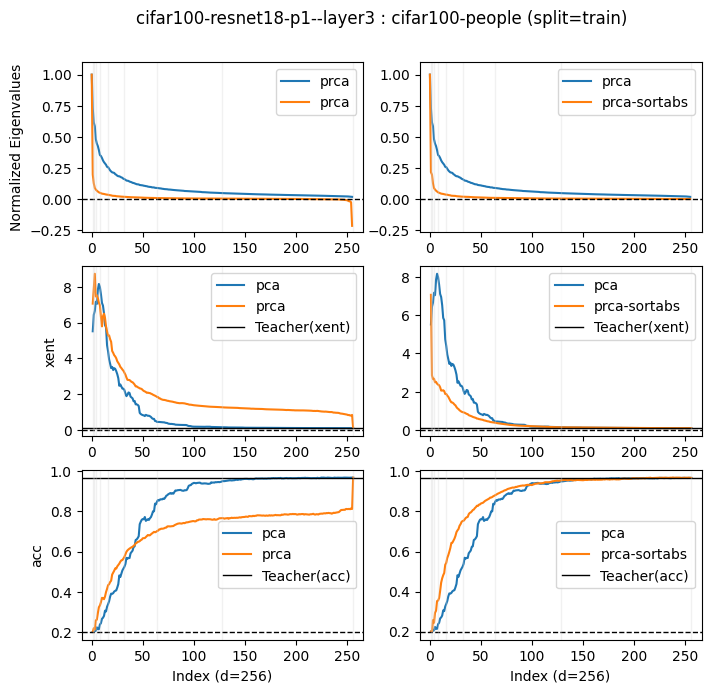

In [35]:
def viz(df_main, split):
    
    df = df_main[df_main.split==split]
    
    d = eigvals_pca.shape[0]
    nrows = 3
    plt.figure(figsize=(4*2, 2.5*nrows))
    
    
    plt.suptitle(
        f"cifar100-resnet18-p1--layer3 : cifar100-people (split={split})",
        y=0.95
    )
    
    vmin = np.min(normalize(eigvals_prca)) - 0.05
    
    plt.subplot(nrows, 2, 1)
    
    plt.ylabel("Normalized Eigenvalues")

    plt.plot(normalize(eigvals_pca), label="prca")
    plt.plot(normalize(eigvals_prca), label="prca")
    plt.axhline(0, ls="--", lw=1, color="k")
    plt.ylim([vmin, 1.1])
    plt.xlim([-10, d+10])
    
    
    plt.legend()
    for j in np.arange(np.log2(d)+1):
        plt.axvline(2**j, ls="-", color="lightgray", alpha=0.3, lw=1)

    
    plt.subplot(nrows, 2, 2)

    plt.plot(normalize(eigvals_pca), label="prca")

    plt.plot(normalize(eigvals_prca_sortabs), label="prca-sortabs")
    plt.legend()
    plt.ylim([vmin, 1.1])
    plt.axhline(0, ls="--", lw=1, color="k")

    plt.xlim([-10, d+10])
    
    for j in np.arange(np.log2(d)+1):
        plt.axvline(2**j, ls="-", color="lightgray", alpha=0.3, lw=1)

    
    
    for cix, col in enumerate(["xent", "acc"]):
        for lsix, label_set in enumerate([
            ['pca', 'prca'],
            ['pca', 'prca-sortabs']

        ]):
            
            lb = 0 if col == "xent" else 0.2

            plt.subplot(nrows, 2, 2*(cix+1)+lsix+1)

            for label in label_set:
                _df = df[df.basis_name == label]
                plt.plot(_df.k, _df[col], label=label)

            if lsix==0:
                plt.ylabel(col)
            teacher_metric = _df[f"teacher_{col}"].values[0]
            plt.axhline(teacher_metric, ls="-", color="k", lw=1, label=f"Teacher({col})")
            plt.axhline(lb, ls="--", color="k", lw=1, )
            plt.legend()

            plt.xlim([-10, d+10])

            if cix == 1:
                plt.xlabel(f"Index (d={d})")

            for j in np.arange(np.log2(d)+1):
                plt.axvline(2**j, ls="-", color="lightgray", alpha=0.3, lw=1)



viz(df, "train")

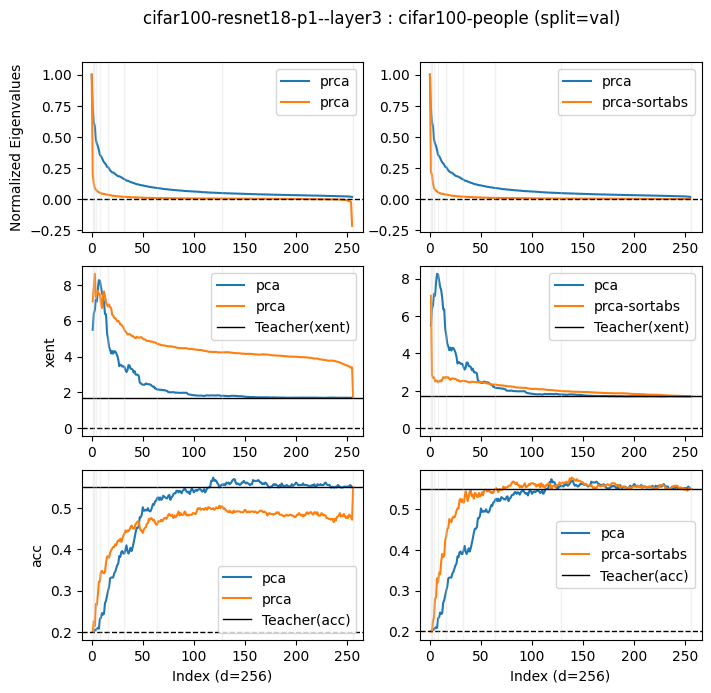

In [36]:
viz(df, "val")

# Summary

## Aim

The experiment aims to relate the spectrum of `pca` and `prca` to the accuracy curve (projection and reconstruction with `k` components)

## Conclusion
- when looking at the curve from `split=train`, we can see that **the spectrum of `prca-abs` correlates  well with the training loss**. 
- **the main trend of the accuracy curves are increasing** with small fluctuations along the way.
- For `prca`, we can see from the very end of *the curve that negative eigenvalues accont for a substantial jump to reach the teacher accuracy*. In contraly, by sorting the  absolute of eigenvalues, we can have a curve with sudden change at the end.


## Follow-up
- replication on different layers, models.
- replicaiton on different classes
- how could we relate the correlation between `prca-sortabs` and `xent(split=train)` to generalization error? 